# Implementing Black Schole pricing with NNs

In [35]:
!pip install cupy-cuda12x

In [36]:
import torch
import torch.nn as nn
#import cupy as cp

In [37]:
# Parameter space
S_lims = [50, 200]
K_lims = [50, 200]
T_lims = [0.02, 3]
r_lims = [0, 0.08]
sigma_lims = [0.05, 0.8]

## BS pricing formula
For a European Call Option:  
$C = S·N(d₁) - K·e^{-rT}·N(d₂)$

Where:

$d_1 = \frac{ln(\frac{S}{K}) + (r + \frac{σ^2}{2})T}{σ\sqrt{T}}$

$d_2 = d_1 - σ\sqrt{T}$

In [38]:
def d1_func(S, K, T, r, sigma):
    return (torch.log(S/K) + (r + (sigma**2)/2)*T) / (sigma * torch.sqrt(T))

def d2_func(d1, T, sigma):
    return d1 - (sigma * torch.sqrt(T))


def bs_call_price(S, K, T, r, sigma):
    d1 = d1_func(S, K, T, r, sigma)
    d2 = d2_func(d1, T, sigma)

    norm = torch.distributions.Normal(0, 1)
    return S * norm.cdf(d1) - K * torch.exp(-r*T) * norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    d1 = d1_func(S, K, T, r, sigma)
    d2 = d2_func(d1, T, sigma)

    norm = torch.distributions.Normal(0, 1)
    return K * torch.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [39]:

# Construct parameter tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

n_samples = 3_000_000

S = torch.rand(n_samples, device=device) * (S_lims[1] - S_lims[0]) + S_lims[0]
K = torch.rand(n_samples, device=device) * (K_lims[1] - K_lims[0]) + K_lims[0]
T = torch.rand(n_samples, device=device) * (T_lims[1] - T_lims[0]) + T_lims[0]
r = torch.rand(n_samples, device=device) * (r_lims[1] - r_lims[0]) + r_lims[0]
sigma = torch.rand(n_samples, device=device) * (sigma_lims[1] - sigma_lims[0]) + sigma_lims[0]

Using device: cuda


In [40]:
from time import perf_counter
start = perf_counter()
call_prices = bs_call_price(S, K, T, r, sigma)
end = perf_counter()

print(f'Generated {call_prices.shape} call prices in {end - start}s')

Generated torch.Size([3000000]) call prices in 0.0024378230000365875s


In [41]:
X = torch.stack([S, K, T, r, sigma], dim=1)  # Shape: (3M, 5)
y = call_prices.unsqueeze(1)  # Shape: (3M, 1)

# Standardize targets
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std

print(f"Target normalization - Mean: {y_mean:.4f}, Std: {y_std:.4f}")

Target normalization - Mean: 38.7203, Std: 36.3050


In [42]:
start = perf_counter()
# Works directly with numpy or torch tensors
indices = torch.randperm(X.shape[0])
split_idx = int(0.98 * X.shape[0])
X_train = X[:split_idx]
X_val = X[split_idx:]
y_train = y_normalized[:split_idx]  # Use normalized
y_val = y_normalized[split_idx:]    # Use normalized
end = perf_counter()
print(f'Split: {end - start}s')

mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std


# Store normalization params for later use
normalization_params = {
    'X_mean': mean.cpu(),
    'X_std': std.cpu(),
    'y_mean': y_mean.cpu(),
    'y_std': y_std.cpu()
}

Split: 0.09693178499992428s


In [43]:
class OptionPricingPINN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256, num_layers=4):
        super(OptionPricingPINN, self).__init__()

        # Input layer
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]

        # Hidden layers
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.Tanh()])

        # Output layer (no activation - we want raw price)
        layers.append(nn.Linear(hidden_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """
        x: (batch_size, 5) tensor of [S, K, T, r, sigma]
        returns: (batch_size, 1) tensor of option prices
        """
        return self.network(x)

In [44]:
def compute_pde_residual(model, X):
    """
    Compute the Black-Scholes PDE residual
    X: (batch_size, 5) tensor of [S, K, T, r, sigma]
    Returns: (batch_size, 1) PDE residual
    """
    # Enable gradient computation for inputs
    X = X.clone().detach().requires_grad_(True)

    # Split inputs
    S = X[:, 0:1]  # Keep dimensions (batch_size, 1)
    K = X[:, 1:2]
    T = X[:, 2:3]
    r = X[:, 3:4]
    sigma = X[:, 4:5]

    # Forward pass
    V = model(X)

    # First derivatives
    dV = torch.autograd.grad(
        outputs=V,
        inputs=X,
        grad_outputs=torch.ones_like(V),
        create_graph=True,  # Need this for second derivatives
        retain_graph=True
    )[0]

    dV_dS = dV[:, 0:1]
    dV_dT = dV[:, 2:3]

    # Second derivative w.r.t. S
    d2V_dS2 = torch.autograd.grad(
        outputs=dV_dS,
        inputs=X,
        grad_outputs=torch.ones_like(dV_dS),
        create_graph=True,
        retain_graph=True
    )[0][:, 0:1]

    # BS PDE: ∂V/∂t + ½σ²S²∂²V/∂S² + rS∂V/∂S - rV = 0
    pde_residual = (dV_dT +
                    0.5 * sigma**2 * S**2 * d2V_dS2 +
                    r * S * dV_dS -
                    r * V)

    return pde_residual

In [45]:
def compute_boundary_loss(model, X_boundary, y_mean, y_std):
    """
    Enforce terminal boundary condition with normalized targets
    """
    V_pred = model(X_boundary)

    # Extract S and K
    S = X_boundary[:, 0:1]
    K = X_boundary[:, 1:2]

    # Terminal condition: intrinsic value
    V_intrinsic = torch.maximum(S - K, torch.zeros_like(S))

    # Normalize intrinsic value to match model's output scale
    V_intrinsic_norm = (V_intrinsic - y_mean) / y_std

    boundary_loss = nn.MSELoss()(V_pred, V_intrinsic_norm)

    return boundary_loss

In [46]:
def generate_boundary_samples(n_samples, device):
    """Generate samples at T ≈ 0"""
    S = torch.rand(n_samples, device=device) * (S_lims[1] - S_lims[0]) + S_lims[0]
    K = torch.rand(n_samples, device=device) * (K_lims[1] - K_lims[0]) + K_lims[0]
    T = torch.ones(n_samples, device=device) * 1e-4  # Very small T
    r = torch.rand(n_samples, device=device) * (r_lims[1] - r_lims[0]) + r_lims[0]
    sigma = torch.rand(n_samples, device=device) * (sigma_lims[1] - sigma_lims[0]) + sigma_lims[0]

    return torch.stack([S, K, T, r, sigma], dim=1)

In [47]:
def combined_loss(model, X, y_true, X_boundary, y_mean, y_std,
                  lambda_pde=1.0, lambda_bc=1.0, compute_physics=True):
    """
    Combined loss: MSE on normalized targets + physics penalty + boundary condition

    Args:
        compute_physics: Whether to compute physics/BC loss (for efficiency)
    """
    # Data loss - USE REGULAR MSE on normalized targets
    # The normalization already makes the loss scale-aware!
    y_pred = model(X)
    mse_loss = nn.MSELoss()(y_pred, y_true)  # Changed from relative_mse_loss

    # Physics and boundary losses (only if needed)
    if compute_physics:
        # Physics loss (PDE residual)
        pde_residual = compute_pde_residual(model, X)
        physics_loss = torch.mean(pde_residual**2)

        # Boundary condition loss
        bc_loss = compute_boundary_loss(model, X_boundary, y_mean, y_std)
    else:
        physics_loss = torch.tensor(0.0, device=X.device)
        bc_loss = torch.tensor(0.0, device=X.device)

    # Combined
    total_loss = mse_loss + lambda_pde * physics_loss + lambda_bc * bc_loss

    return total_loss, mse_loss, physics_loss, bc_loss

In [48]:
from tqdm import tqdm

def train_pinn(model, X_train, y_train, X_val, y_val, X_boundary,
               y_mean, y_std,  # NEW: Add normalization params
               epochs=100, batch_size=4096, lr=1e-3,
               lambda_pde=1.0, lambda_bc=1.0, device='cuda',
               physics_freq=5, val_freq=5):
    """
    Training loop for PINN with optimized physics loss computation

    Args:
        y_mean: Mean of target values (for denormalization in BC loss)
        y_std: Std of target values (for denormalization in BC loss)
        physics_freq: Compute physics/BC loss every N batches (default: 5)
        val_freq: Validate every N epochs (default: 5)
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # NEW: CosineAnnealingLR - smooth decay to min_lr over entire training
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=lr * 0.01  # Decay to 1% of initial lr
    )

    # Move data to device
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    X_boundary = X_boundary.to(device)
    y_mean = y_mean.to(device)
    y_std = y_std.to(device)

    # Training history
    history = {
        'train_loss': [], 'train_mse': [], 'train_physics': [], 'train_bc': [],
        'val_loss': [], 'val_mse': [], 'val_physics': [], 'val_bc': [],
        'lr': []  # NEW: Track learning rate
    }

    # Create DataLoaders for both train and validation
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False
    )

    best_val_loss = float('inf')

    # Regular for loop for epochs (no tqdm at epoch level)
    for epoch in range(epochs):
        # NEW: Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch [{epoch+1}/{epochs}] - LR: {current_lr:.2e}")

        # Training
        model.train()
        epoch_losses = {'total': 0, 'mse': 0, 'physics': 0, 'bc': 0}
        physics_count = 0

        # Training batch progress bar
        train_pbar = tqdm(enumerate(train_loader),
                         total=len(train_loader),
                         desc="Training",
                         unit="batch")

        for batch_idx, (batch_X, batch_y) in train_pbar:
            optimizer.zero_grad()

            # Compute loss with normalized targets
            total_loss, mse_loss, physics_loss, bc_loss = combined_loss(
                model, batch_X, batch_y, X_boundary,
                y_mean, y_std,
                lambda_pde, lambda_bc,
                compute_physics=(batch_idx % physics_freq == 0)
            )

            if batch_idx % physics_freq == 0:
                physics_count += 1

            # Backward pass
            total_loss.backward()
            optimizer.step()

            # Track losses
            epoch_losses['total'] += total_loss.item()
            epoch_losses['mse'] += mse_loss.item()
            epoch_losses['physics'] += physics_loss.item()
            epoch_losses['bc'] += bc_loss.item()

            # Update progress bar with current batch loss
            train_pbar.set_postfix({
                'loss': f"{total_loss.item():.4f}",
                'mse': f"{mse_loss.item():.4f}"
            })

        # Average training losses
        n_batches = len(train_loader)
        epoch_losses['total'] /= n_batches
        epoch_losses['mse'] /= n_batches
        if physics_count > 0:
            epoch_losses['physics'] /= physics_count
            epoch_losses['bc'] /= physics_count

        # Validation - only every val_freq epochs
        if (epoch + 1) % val_freq == 0 or epoch == 0:
            model.eval()
            val_losses = {'total': 0, 'mse': 0, 'physics': 0, 'bc': 0}

            # Validation batch progress bar
            val_pbar = tqdm(val_loader,
                           desc="Validation",
                           unit="batch")

            for batch_X, batch_y in val_pbar:
                # Compute validation loss (always compute physics for validation)
                with torch.no_grad():
                    y_pred = model(batch_X)
                    batch_mse = nn.MSELoss()(y_pred, batch_y)

                # Physics loss (needs gradients)
                pde_residual = compute_pde_residual(model, batch_X)
                batch_physics = torch.mean(pde_residual**2)

                # Accumulate
                val_losses['mse'] += batch_mse.item()
                val_losses['physics'] += batch_physics.item()

                # Update progress bar
                val_pbar.set_postfix({
                    'mse': f"{batch_mse.item():.4f}",
                    'physics': f"{batch_physics.item():.4f}"
                })

            # Compute BC loss ONCE
            val_bc = compute_boundary_loss(model, X_boundary, y_mean, y_std)
            val_losses['bc'] = val_bc.item()

            # Average validation losses
            n_val_batches = len(val_loader)
            val_losses['mse'] /= n_val_batches
            val_losses['physics'] /= n_val_batches
            val_losses['total'] = (val_losses['mse'] +
                                   lambda_pde * val_losses['physics'] +
                                   lambda_bc * val_losses['bc'])

            # Checkpointing
            if val_losses['total'] < best_val_loss:
                best_val_loss = val_losses['total']
                torch.save(model.state_dict(), 'best_pinn_model.pt')
                print(f"  → New best model saved (val_loss: {best_val_loss:.6f})")
        else:
            # Use previous validation losses
            val_losses = {
                'total': history['val_loss'][-1] if history['val_loss'] else 0,
                'mse': history['val_mse'][-1] if history['val_mse'] else 0,
                'physics': history['val_physics'][-1] if history['val_physics'] else 0,
                'bc': history['val_bc'][-1] if history['val_bc'] else 0
            }

        # Store history
        history['train_loss'].append(epoch_losses['total'])
        history['train_mse'].append(epoch_losses['mse'])
        history['train_physics'].append(epoch_losses['physics'])
        history['train_bc'].append(epoch_losses['bc'])
        history['val_loss'].append(val_losses['total'])
        history['val_mse'].append(val_losses['mse'])
        history['val_physics'].append(val_losses['physics'])
        history['val_bc'].append(val_losses['bc'])
        history['lr'].append(current_lr)  # NEW: Store learning rate

        # Print epoch summary
        print(f"  Train - Total: {epoch_losses['total']:.6f}, "
              f"MSE: {epoch_losses['mse']:.6f}, "
              f"Physics: {epoch_losses['physics']:.6f}, "
              f"BC: {epoch_losses['bc']:.6f}")
        print(f"  Val   - Total: {val_losses['total']:.6f}, "
              f"MSE: {val_losses['mse']:.6f}, "
              f"Physics: {val_losses['physics']:.6f}, "
              f"BC: {val_losses['bc']:.6f}")

        # NEW: Step scheduler at end of epoch
        scheduler.step()

    return history

In [49]:
# Initialize model
model = OptionPricingPINN(input_dim=5, hidden_dim=256, num_layers=4)

# Generate boundary samples
X_boundary = generate_boundary_samples(n_samples=10000, device=device)

# Train with optimized settings
history = train_pinn(
    model, X_train_norm, y_train, X_val_norm, y_val, X_boundary,
    y_mean, y_std,  # NEW: Pass normalization params
    epochs=100, batch_size=4096, lr=1e-3,
    lambda_pde=0, lambda_bc=1.0, device=device,
    physics_freq=5, val_freq=5
)


Epoch [1/100] - LR: 1.00e-03


Validation: 100%|██████████| 15/15 [00:00<00:00, 22.50batch/s, mse=0.0039, physics=0.7552]


  → New best model saved (val_loss: 0.041868)
  Train - Total: 0.057209, MSE: 0.035463, Physics: 0.686331, BC: 0.108433
  Val   - Total: 0.041868, MSE: 0.003979, Physics: 0.746593, BC: 0.037889

Epoch [2/100] - LR: 1.00e-03


Training: 100%|██████████| 718/718 [00:36<00:00, 19.69batch/s, loss=0.0054, mse=0.0054]


  Train - Total: 0.013305, MSE: 0.004468, Physics: 0.760531, BC: 0.044063
  Val   - Total: 0.041868, MSE: 0.003979, Physics: 0.746593, BC: 0.037889

Epoch [3/100] - LR: 9.99e-04


...

  Train - Total: 0.000003, MSE: 0.000002, Physics: 1.864314, BC: 0.000004
  Val   - Total: 0.000006, MSE: 0.000002, Physics: 1.943970, BC: 0.000004

Epoch [99/100] - LR: 1.10e-05


Training: 100%|██████████| 718/718 [00:36<00:00, 19.67batch/s, loss=0.0000, mse=0.0000]


  Train - Total: 0.000003, MSE: 0.000002, Physics: 1.829580, BC: 0.000004
  Val   - Total: 0.000006, MSE: 0.000002, Physics: 1.943970, BC: 0.000004

Epoch [100/100] - LR: 1.02e-05


Validation: 100%|██████████| 15/15 [00:00<00:00, 21.83batch/s, mse=0.0000, physics=1.9031]

  → New best model saved (val_loss: 0.000005)
  Train - Total: 0.000003, MSE: 0.000002, Physics: 1.847002, BC: 0.000004
  Val   - Total: 0.000005, MSE: 0.000002, Physics: 1.876680, BC: 0.000003


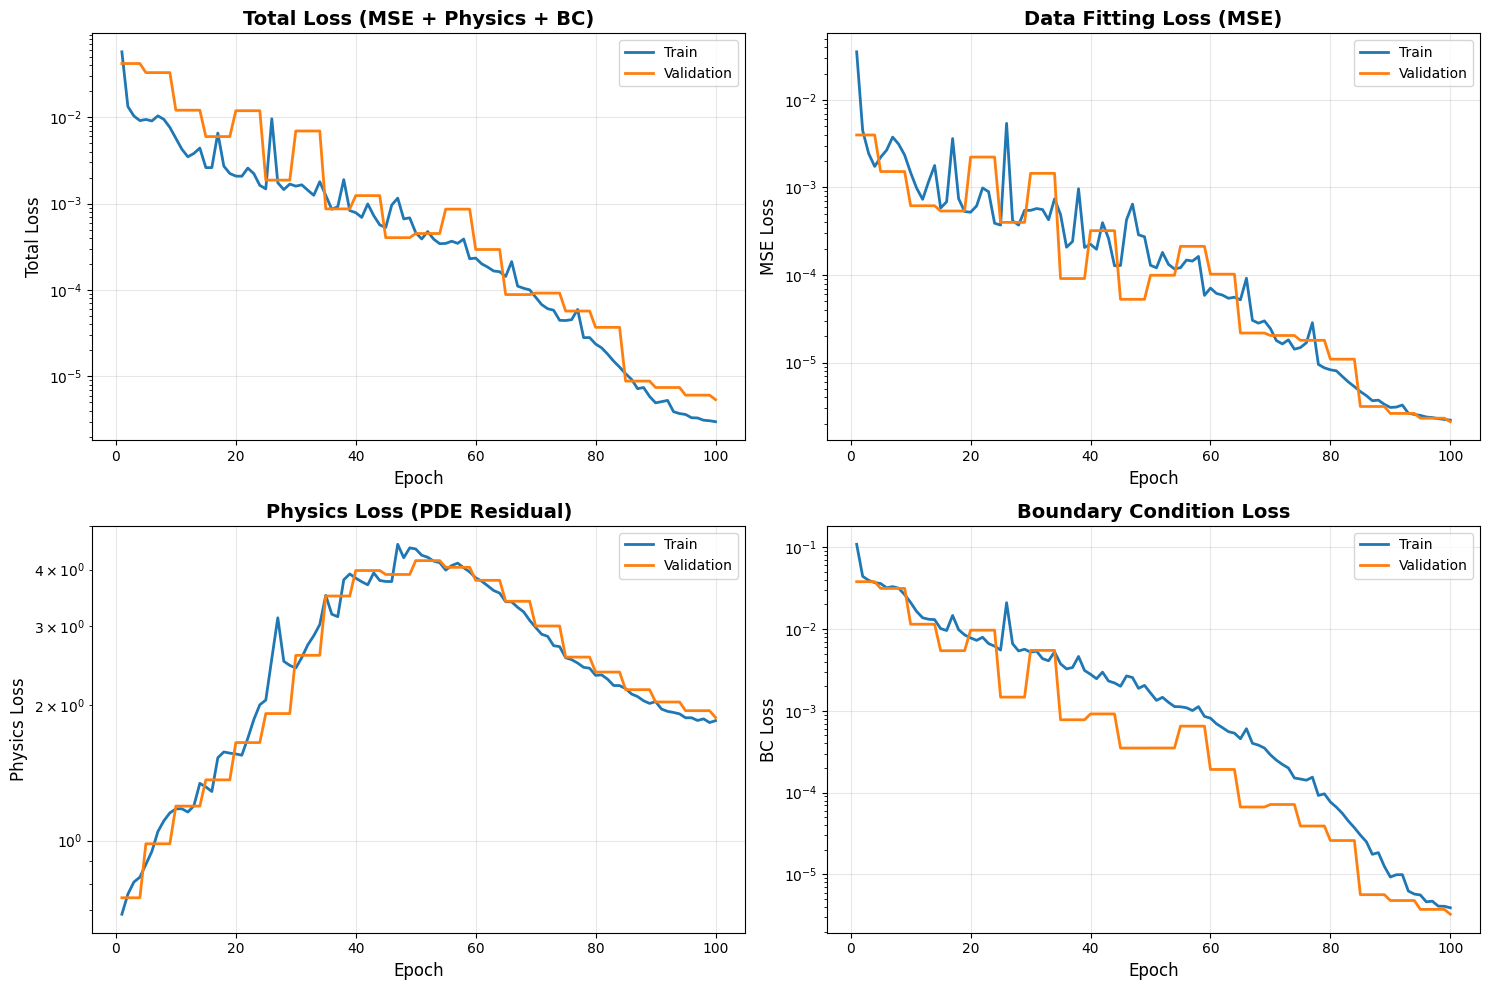

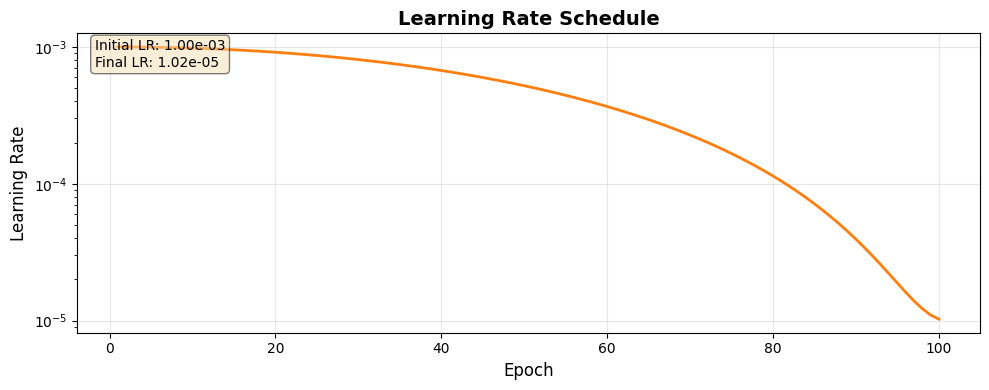

In [50]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plot training history with separate subplots for each loss component
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    epochs = range(1, len(history['train_loss']) + 1)

    # Total Loss
    axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Total Loss', fontsize=12)
    axes[0, 0].set_title('Total Loss (MSE + Physics + BC)', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_yscale('log')  # Log scale often better for loss

    # MSE Loss (Data Fitting)
    axes[0, 1].plot(epochs, history['train_mse'], label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_mse'], label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('MSE Loss', fontsize=12)
    axes[0, 1].set_title('Data Fitting Loss (MSE)', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')

    # Physics Loss (PDE Residual)
    axes[1, 0].plot(epochs, history['train_physics'], label='Train', linewidth=2)
    axes[1, 0].plot(epochs, history['val_physics'], label='Validation', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Physics Loss', fontsize=12)
    axes[1, 0].set_title('Physics Loss (PDE Residual)', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')

    # Boundary Condition Loss
    axes[1, 1].plot(epochs, history['train_bc'], label='Train', linewidth=2)
    axes[1, 1].plot(epochs, history['val_bc'], label='Validation', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('BC Loss', fontsize=12)
    axes[1, 1].set_title('Boundary Condition Loss', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    # NEW: Separate figure for learning rate
    fig_lr, ax_lr = plt.subplots(figsize=(10, 4))

    ax_lr.plot(epochs, history['lr'], linewidth=2, color='tab:orange')
    ax_lr.set_xlabel('Epoch', fontsize=12)
    ax_lr.set_ylabel('Learning Rate', fontsize=12)
    ax_lr.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax_lr.grid(True, alpha=0.3)
    ax_lr.set_yscale('log')  # Log scale to see the decay clearly

    # Add text annotation showing initial and final LR
    initial_lr = history['lr'][0]
    final_lr = history['lr'][-1]
    ax_lr.text(0.02, 0.98, f'Initial LR: {initial_lr:.2e}\nFinal LR: {final_lr:.2e}',
               transform=ax_lr.transAxes, fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('learning_rate_schedule.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage after training
plot_training_history(history)

In [51]:
# Save the final trained model
import os
from datetime import datetime

# Create a models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Generate timestamp for filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the final model state
final_model_path = f'models/pinn_final_{timestamp}.pt'
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to: {final_model_path}")

# Also save the best model with timestamp (copy from training)
if os.path.exists('best_pinn_model.pt'):
    best_model_path = f'models/pinn_best_{timestamp}.pt'
    torch.save(torch.load('best_pinn_model.pt'), best_model_path)
    print(f"Best model saved to: {best_model_path}")

# Save training history
history_path = f'models/training_history_{timestamp}.pt'
torch.save(history, history_path)
print(f"Training history saved to: {history_path}")

# Optional: Save complete checkpoint with optimizer state for resuming training
checkpoint = {
    'model_state_dict': model.state_dict(),
    'history': history,
    'normalization': {
        'X_mean': mean.cpu(),
        'X_std': std.cpu(),
        'y_mean': y_mean.cpu(),  # ADD THIS
        'y_std': y_std.cpu()      # ADD THIS
    },
    'config': {
        'input_dim': 5,
        'hidden_dim': 256,
        'num_layers': 4,
        'lambda_pde': 0.05,  # Updated value
        'lambda_bc': 1.0
    }
}
checkpoint_path = f'models/pinn_checkpoint_{timestamp}.pt'
torch.save(checkpoint, checkpoint_path)
print(f"Full checkpoint saved to: {checkpoint_path}")

print("\n" + "="*70)
print("All models and artifacts saved successfully!")
print("="*70)

Final model saved to: models/pinn_final_20260213_235621.pt
Best model saved to: models/pinn_best_20260213_235621.pt
Training history saved to: models/training_history_20260213_235621.pt
Full checkpoint saved to: models/pinn_checkpoint_20260213_235621.pt

All models and artifacts saved successfully!


VALIDATION SET METRICS (Original Price Scale)
R² Score:              0.999998
RMSE:                  $0.0526
MAE:                   $0.0370
MAPE (non-zero):       1.6103%
Mean Relative Error:   1.6103%
Median Relative Error: 0.1040%
Max Relative Error:    753.2006%
Samples evaluated:     60,000
Non-zero samples:      56,004 (93.3%)


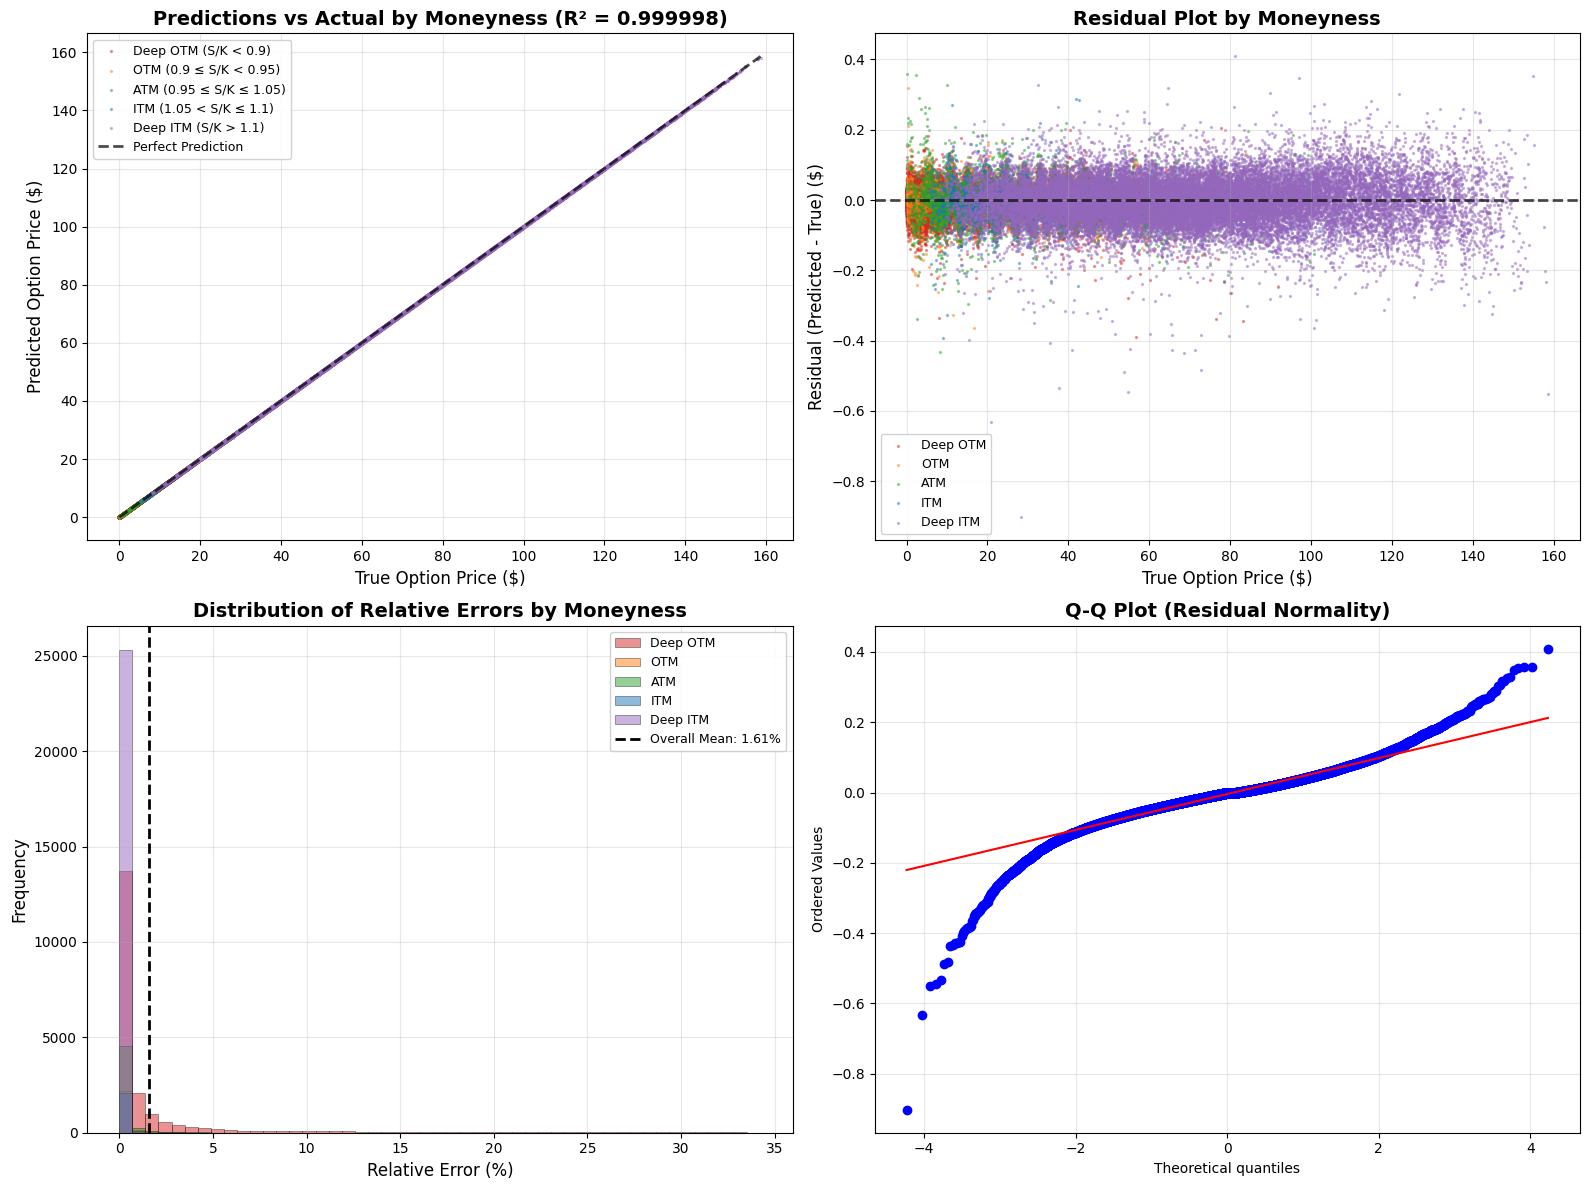


ERROR ANALYSIS BY MONEYNESS
Deep OTM (S/K < 0.9)      - Count:   24876, MAE: $  0.02, MAPE:   3.87%, R²: 0.999993
OTM (0.9 ≤ S/K < 0.95)    - Count:    2560, MAE: $  0.04, MAPE:   1.23%, R²: 0.999992
ATM (0.95 ≤ S/K ≤ 1.05)   - Count:    4999, MAE: $  0.04, MAPE:   0.71%, R²: 0.999992
ITM (1.05 < S/K ≤ 1.1)    - Count:    2169, MAE: $  0.04, MAPE:   0.18%, R²: 0.999992
Deep ITM (S/K > 1.1)      - Count:   25396, MAE: $  0.05, MAPE:   0.08%, R²: 0.999995


In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Evaluation on validation set
model.eval()
with torch.no_grad():
    # Get predictions on validation set (normalized)
    y_pred_val_norm = model(X_val_norm)

    # Denormalize predictions and true values back to original scale
    y_pred_val = (y_pred_val_norm * y_std + y_mean).cpu().numpy()
    y_true_val = (y_val * y_std + y_mean).cpu().numpy()

    # Clamp predictions to be non-negative
    y_pred_val = np.maximum(y_pred_val, 0)

# Calculate metrics (now on original price scale)
r2 = r2_score(y_true_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
mae = mean_absolute_error(y_true_val, y_pred_val)

# Calculate relative error only for non-zero true values
non_zero_mask = y_true_val > 0.01
relative_error_valid = np.abs((y_true_val[non_zero_mask] - y_pred_val[non_zero_mask]) / y_true_val[non_zero_mask]) * 100
mape = np.mean(relative_error_valid)

print("="*70)
print("VALIDATION SET METRICS (Original Price Scale)")
print("="*70)
print(f"R² Score:              {r2:.6f}")
print(f"RMSE:                  ${rmse:.4f}")
print(f"MAE:                   ${mae:.4f}")
print(f"MAPE (non-zero):       {mape:.4f}%")
print(f"Mean Relative Error:   {relative_error_valid.mean():.4f}%")
print(f"Median Relative Error: {np.median(relative_error_valid):.4f}%")
print(f"Max Relative Error:    {relative_error_valid.max():.4f}%")
print(f"Samples evaluated:     {len(y_true_val):,}")
print(f"Non-zero samples:      {non_zero_mask.sum():,} ({100*non_zero_mask.sum()/len(y_true_val):.1f}%)")
print("="*70)

# Calculate moneyness categories BEFORE plotting
X_val_denorm = (X_val * std + mean).cpu()
S_val = X_val_denorm[:, 0].numpy()
K_val = X_val_denorm[:, 1].numpy()
moneyness = S_val / K_val

# Define moneyness categories
deep_otm = (moneyness < 0.9)
otm = (moneyness >= 0.9) & (moneyness < 0.95)
atm = (moneyness >= 0.95) & (moneyness <= 1.05)
itm = (moneyness > 1.05) & (moneyness <= 1.1)
deep_itm = (moneyness > 1.1)

# Color scheme
colors = {
    'Deep OTM': '#d62728',  # Red
    'OTM': '#ff7f0e',       # Orange
    'ATM': '#2ca02c',       # Green
    'ITM': '#1f77b4',       # Blue
    'Deep ITM': '#9467bd'   # Purple
}

# Create comprehensive plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predictions vs Actual (scatter) - COLOR CODED BY MONEYNESS
axes[0, 0].scatter(y_true_val[deep_otm], y_pred_val[deep_otm],
                   alpha=0.4, s=2, c=colors['Deep OTM'], label='Deep OTM (S/K < 0.9)')
axes[0, 0].scatter(y_true_val[otm], y_pred_val[otm],
                   alpha=0.4, s=2, c=colors['OTM'], label='OTM (0.9 ≤ S/K < 0.95)')
axes[0, 0].scatter(y_true_val[atm], y_pred_val[atm],
                   alpha=0.4, s=2, c=colors['ATM'], label='ATM (0.95 ≤ S/K ≤ 1.05)')
axes[0, 0].scatter(y_true_val[itm], y_pred_val[itm],
                   alpha=0.4, s=2, c=colors['ITM'], label='ITM (1.05 < S/K ≤ 1.1)')
axes[0, 0].scatter(y_true_val[deep_itm], y_pred_val[deep_itm],
                   alpha=0.4, s=2, c=colors['Deep ITM'], label='Deep ITM (S/K > 1.1)')

axes[0, 0].plot([y_true_val.min(), y_true_val.max()],
                [y_true_val.min(), y_true_val.max()],
                'k--', lw=2, label='Perfect Prediction', alpha=0.7)
axes[0, 0].set_xlabel('True Option Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Option Price ($)', fontsize=12)
axes[0, 0].set_title(f'Predictions vs Actual by Moneyness (R² = {r2:.6f})', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='upper left', fontsize=9, framealpha=0.9)
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals (prediction errors) - COLOR CODED BY MONEYNESS
residuals = y_pred_val - y_true_val

axes[0, 1].scatter(y_true_val[deep_otm], residuals[deep_otm],
                   alpha=0.4, s=2, c=colors['Deep OTM'], label='Deep OTM')
axes[0, 1].scatter(y_true_val[otm], residuals[otm],
                   alpha=0.4, s=2, c=colors['OTM'], label='OTM')
axes[0, 1].scatter(y_true_val[atm], residuals[atm],
                   alpha=0.4, s=2, c=colors['ATM'], label='ATM')
axes[0, 1].scatter(y_true_val[itm], residuals[itm],
                   alpha=0.4, s=2, c=colors['ITM'], label='ITM')
axes[0, 1].scatter(y_true_val[deep_itm], residuals[deep_itm],
                   alpha=0.4, s=2, c=colors['Deep ITM'], label='Deep ITM')

axes[0, 1].axhline(y=0, color='k', linestyle='--', lw=2, alpha=0.7)
axes[0, 1].set_xlabel('True Option Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Residual (Predicted - True) ($)', fontsize=12)
axes[0, 1].set_title('Residual Plot by Moneyness', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='best', fontsize=9, framealpha=0.9)
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of relative errors by moneyness - STACKED OR OVERLAID
# Calculate relative errors for each category
categories_data = {
    'Deep OTM': deep_otm,
    'OTM': otm,
    'ATM': atm,
    'ITM': itm,
    'Deep ITM': deep_itm
}

relative_errors_by_category = {}
for cat_name, mask in categories_data.items():
    cat_mask = mask & (y_true_val.flatten() > 0.01)
    if cat_mask.sum() > 0:
        cat_rel_error = np.abs((y_true_val[cat_mask] - y_pred_val[cat_mask]) / y_true_val[cat_mask]) * 100
        relative_errors_by_category[cat_name] = cat_rel_error.flatten()

# Overlay histograms with transparency
bins = np.linspace(0, min(50, np.percentile(relative_error_valid, 99)), 50)
for cat_name, rel_errors in relative_errors_by_category.items():
    axes[1, 0].hist(rel_errors, bins=bins, alpha=0.5,
                    label=cat_name, color=colors[cat_name], edgecolor='black', linewidth=0.5)

axes[1, 0].axvline(relative_error_valid.mean(), color='black', linestyle='--',
                   linewidth=2, label=f'Overall Mean: {relative_error_valid.mean():.2f}%')
axes[1, 0].set_xlabel('Relative Error (%)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Relative Errors by Moneyness', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=9, framealpha=0.9)
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot (check if residuals are normally distributed)
from scipy import stats
stats.probplot(residuals.flatten(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Residual Normality)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinn_evaluation_moneyness.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional analysis: Error by moneyness
print("\n" + "="*70)
print("ERROR ANALYSIS BY MONEYNESS")
print("="*70)

# Denormalize X_val to get original S and K values
X_val_denorm = (X_val * std + mean).cpu()

S_val = X_val_denorm[:, 0].numpy()
K_val = X_val_denorm[:, 1].numpy()
moneyness = S_val / K_val

# Categorize by moneyness
deep_otm = (moneyness < 0.9)
otm = (moneyness >= 0.9) & (moneyness < 0.95)
atm = (moneyness >= 0.95) & (moneyness <= 1.05)
itm = (moneyness > 1.05) & (moneyness <= 1.1)
deep_itm = (moneyness > 1.1)

categories = {
    'Deep OTM (S/K < 0.9)': deep_otm,
    'OTM (0.9 ≤ S/K < 0.95)': otm,
    'ATM (0.95 ≤ S/K ≤ 1.05)': atm,
    'ITM (1.05 < S/K ≤ 1.1)': itm,
    'Deep ITM (S/K > 1.1)': deep_itm
}

for cat_name, mask in categories.items():
    if mask.sum() > 0:
        cat_y_true = y_true_val[mask]
        cat_y_pred = y_pred_val[mask]

        # Calculate metrics
        cat_r2 = r2_score(cat_y_true, cat_y_pred)
        cat_mae = mean_absolute_error(cat_y_true, cat_y_pred)

        # Only calculate MAPE for non-zero prices in this category
        cat_non_zero = cat_y_true > 0.01
        if cat_non_zero.sum() > 0:
            cat_mape = np.mean(np.abs((cat_y_true[cat_non_zero] - cat_y_pred[cat_non_zero]) / cat_y_true[cat_non_zero])) * 100
        else:
            cat_mape = np.nan

        print(f"{cat_name:25s} - Count: {mask.sum():7d}, MAE: ${cat_mae:6.2f}, MAPE: {cat_mape:6.2f}%, R²: {cat_r2:.6f}")

print("="*70)

In [53]:
# Load the final model
loaded_model = OptionPricingPINN(input_dim=5, hidden_dim=256, num_layers=4)
loaded_model.load_state_dict(torch.load('models/pinn_final_TIMESTAMP.pt'))
loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully!")

# Or load the full checkpoint
checkpoint = torch.load('models/pinn_checkpoint_TIMESTAMP.pt')
loaded_model = OptionPricingPINN(
    input_dim=checkpoint['config']['input_dim'],
    hidden_dim=checkpoint['config']['hidden_dim'],
    num_layers=checkpoint['config']['num_layers']
)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.to(device)
loaded_model.eval()

# Retrieve normalization parameters
mean = checkpoint['normalization']['mean'].to(device)
std = checkpoint['normalization']['std'].to(device)

# Retrieve history
history = checkpoint['history']

print("Checkpoint loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/pinn_final_TIMESTAMP.pt'